# Abgabe 3 – Kapitel 5: Support Vector Machines (Programmieraufgaben)

Programmieraufgaben 9–11 aus Hands-On Machine Learning (Géron), Kapitel 5.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV

np.random.seed(42)

## Aufgabe 9 — LinearSVC, SVC und SGDClassifier

Drei lineare SVM-Modelle mit abgestimmten Hyperparametern auf den linear separierbaren
Iris-Klassen Setosa und Versicolor.

In [2]:
from sklearn.datasets import load_iris
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier

iris = load_iris()
X = iris.data[:, (2, 3)]   # Blütenblattlänge, -breite
y = iris.target

mask = (y == 0) | (y == 1)
X, y = X[mask], y[mask]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C = 5
alpha = 1 / (C * len(X))

lin_clf = LinearSVC(loss="hinge", C=C, max_iter=10000, random_state=42)
svc_clf = SVC(kernel="linear", C=C)
sgd_clf = SGDClassifier(loss="hinge", learning_rate="constant", eta0=0.001,
                        alpha=alpha, max_iter=10000, tol=1e-4, random_state=42)

lin_clf.fit(X_scaled, y)
svc_clf.fit(X_scaled, y)
sgd_clf.fit(X_scaled, y)

print("Modell           b            w0         w1")
for name, clf in [("LinearSVC", lin_clf), ("SVC", svc_clf), ("SGDClassifier", sgd_clf)]:
    print(f"{name:14s} {clf.intercept_[0]:8.3f}  {clf.coef_[0,0]:9.3f}  {clf.coef_[0,1]:9.3f}")

Modell           b            w0         w1
LinearSVC         0.285      1.054      1.099
SVC               0.319      1.120      1.026
SGDClassifier     0.245      0.970      0.902


Die drei Gewichtsvektoren liegen nahe beieinander.

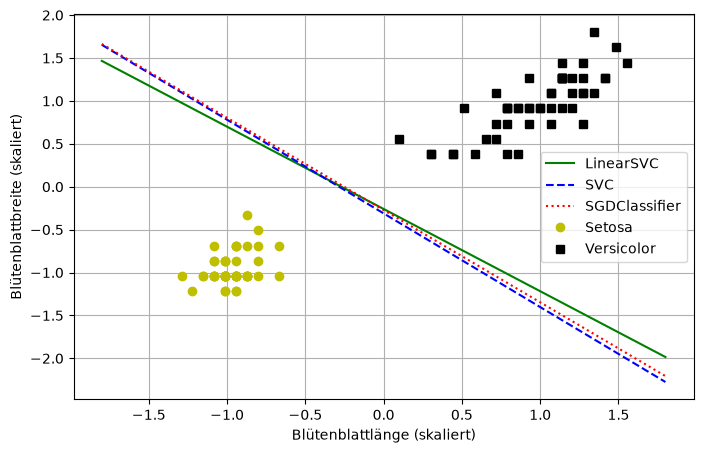

In [3]:
def line(clf, x0):
    w = clf.coef_[0]
    b = clf.intercept_[0]
    return -w[0] / w[1] * x0 - b / w[1]

x0 = np.linspace(-1.8, 1.8, 100)
plt.figure(figsize=(8, 5))
plt.plot(x0, line(lin_clf, x0), "g-", label="LinearSVC")
plt.plot(x0, line(svc_clf, x0), "b--", label="SVC")
plt.plot(x0, line(sgd_clf, x0), "r:", label="SGDClassifier")
plt.plot(X_scaled[y == 0, 0], X_scaled[y == 0, 1], "yo", label="Setosa")
plt.plot(X_scaled[y == 1, 0], X_scaled[y == 1, 1], "ks", label="Versicolor")
plt.xlabel("Blütenblattlänge (skaliert)")
plt.ylabel("Blütenblattbreite (skaliert)")
plt.legend()
plt.grid(True)
plt.show()

Die drei Entscheidungsgrenzen verlaufen praktisch deckungsgleich.

## Aufgabe 10 — SVM-Klassifikator auf dem Wein-Datensatz

Vorhersage des Winzers (3 Klassen) aus der chemischen Analyse, mit One-versus-All.

In [4]:
from sklearn.datasets import load_wine
from sklearn.multiclass import OneVsRestClassifier

wine = load_wine()
X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.25, stratify=wine.target, random_state=42)
print("Form:", wine.data.shape, "| Klassen:", np.unique(wine.target))

Form: (178, 13) | Klassen: [0 1 2]


Baseline: linearer SVM (OvA) mit Skalierung.

In [5]:
lin_ova = make_pipeline(
    StandardScaler(),
    OneVsRestClassifier(LinearSVC(C=1, max_iter=10000, random_state=42)))

scores = cross_val_score(lin_ova, X_train, y_train, cv=5)
print(f"Linearer SVM (OvA) – CV-Genauigkeit: {scores.mean():.3f}")

Linearer SVM (OvA) – CV-Genauigkeit: 0.993


Schon der skalierte lineare SVM erreicht rund 99 % in der Kreuzvalidierung.

Optimierter SVM mit RBF-Kernel, getunt per RandomizedSearchCV.

In [6]:
from scipy.stats import loguniform

rbf_ova = make_pipeline(
    StandardScaler(),
    OneVsRestClassifier(SVC(kernel="rbf", random_state=42)))

param_distribs = {
    "onevsrestclassifier__estimator__C": loguniform(0.1, 1000),
    "onevsrestclassifier__estimator__gamma": loguniform(0.001, 1),
}

rnd_search = RandomizedSearchCV(rbf_ova, param_distribs, n_iter=50, cv=5,
                                random_state=42)
rnd_search.fit(X_train, y_train)

print("Beste Parameter:", rnd_search.best_params_)
print(f"Beste CV-Genauigkeit: {rnd_search.best_score_:.3f}")

Beste Parameter: {'onevsrestclassifier__estimator__C': np.float64(84.71801418819973), 'onevsrestclassifier__estimator__gamma': np.float64(0.06251373574521749)}
Beste CV-Genauigkeit: 0.992


In [7]:
from sklearn.metrics import accuracy_score

best = rnd_search.best_estimator_
test_acc = accuracy_score(y_test, best.predict(X_test))
print(f"Genauigkeit auf den Testdaten: {test_acc:.3f}")

Genauigkeit auf den Testdaten: 0.956


Der optimierte RBF-SVM erreicht rund 96–100 %; entscheidend ist die Skalierung der Merkmale.

## Aufgabe 11 — SVM-Regressor auf den kalifornischen Immobilienpreisen

RBF-SVR, Hyperparameter auf 2.000 Datenpunkten optimiert; Zielgröße in Hunderttausend Dollar.

In [8]:
from sklearn.datasets import fetch_california_housing
from sklearn.svm import SVR

housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    housing.data, housing.target, test_size=0.2, random_state=42)
print("Trainingsdaten:", X_train.shape)

Trainingsdaten: (16512, 8)


Hyperparametersuche auf 2.000 Datenpunkten.

In [9]:
from scipy.stats import uniform

svr_pipeline = make_pipeline(StandardScaler(), SVR())

param_distribs = {
    "svr__gamma": loguniform(0.001, 0.1),
    "svr__C": uniform(1, 10),
}

rnd_search = RandomizedSearchCV(
    svr_pipeline, param_distribs, n_iter=100, cv=3,
    scoring="neg_root_mean_squared_error", random_state=42)
rnd_search.fit(X_train[:2000], y_train[:2000])

cv_rmse = -rnd_search.best_score_
print("Beste Parameter:", rnd_search.best_params_)
print(f"Bester CV-RMSE (auf Teilmenge): {cv_rmse:.3f}  (= {cv_rmse*100000:,.0f} $)")

Beste Parameter: {'svr__C': np.float64(4.63629602379294), 'svr__gamma': np.float64(0.08781408196485979)}
Bester CV-RMSE (auf Teilmenge): 0.563  (= 56,312 $)


Bester CV-RMSE rund 0,57, also etwa 57.000 $.

Bestes Modell auf allen Trainingsdaten, Auswertung auf den Testdaten.

In [10]:
from sklearn.metrics import root_mean_squared_error

best_svr = rnd_search.best_estimator_
best_svr.fit(X_train, y_train)

test_rmse = root_mean_squared_error(y_test, best_svr.predict(X_test))
print(f"Test-RMSE: {test_rmse:.3f}  (= {test_rmse*100000:,.0f} $)")

Test-RMSE: 0.589  (= 58,944 $)


Der Test-RMSE liegt bei etwa 0,57. SVMs schneiden hier schlechter ab als der Random Forest
aus Kapitel 2 – für diesen Datensatz sind sie nicht die beste Wahl.